In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter

In [36]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

In [37]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)
classic=parse('166_Mg_blues.assoc.txt.gz')

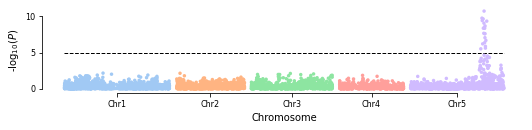

In [42]:
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
# fig = plt.figure(figsize=(22*cm,4*cm))
fig = plt.figure(figsize=(22*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=classic,
                hue='chr',
                palette='pastel',
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.savefig("Fig4a_20250108.png", format="png",bbox_inches="tight",facecolor="w",dpi=600)

In [41]:
significant_SNP=classic[classic['P'] > -np.log10(0.05/len(classic))]
significant_SNP

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
4759,5,5:20319734,20319734,11,A,G,0.155,-169.2313,31.06862,1.668927,1.650040,1.844506e-07,2.916173e-06,5.673193e-05,5.535187,-5.535187,120490580
4773,5,5:20656234,20656234,9,T,A,0.166,-228.5551,29.36752,1.171003,1.148314,7.553945e-13,1.692426e-10,2.465137e-07,9.771490,-9.771490,120827080
4776,5,5:20743393,20743393,14,T,C,0.171,-207.7317,27.51054,1.249202,1.235758,2.851469e-12,3.657746e-10,2.994742e-07,9.436786,-9.436786,120914239
4780,5,5:20859536,20859536,12,G,A,0.104,-202.2775,37.54559,2.293652,2.285104,2.445625e-07,6.014741e-07,7.850611e-06,6.220783,-6.220783,121030382
4785,5,5:21004524,21004524,13,G,G,0.170,-227.2776,29.07069,1.114395,1.092585,6.152074e-13,2.181185e-10,3.797196e-07,9.661307,-9.661307,121175370
4788,5,5:21057767,21057767,14,A,G,0.164,-215.0527,29.69010,1.160780,1.138054,1.619039e-11,4.190220e-09,1.905941e-06,8.377763,-8.377763,121228613
4794,5,5:21182471,21182471,15,C,T,0.166,-204.2840,29.15321,1.127547,1.107070,5.988825e-11,2.095829e-08,7.112796e-06,7.678644,-7.678644,121353317
4797,5,5:21229825,21229825,15,C,T,0.166,-218.2507,28.82106,1.124504,1.105053,2.520719e-12,8.448214e-10,8.034689e-07,9.073235,-9.073235,121400671
4801,5,5:21271637,21271637,12,G,A,0.175,-234.3259,28.57560,1.140754,1.117081,6.597850e-14,1.796790e-11,6.131277e-08,10.745503,-10.745503,121442483
4804,5,5:21314026,21314026,14,G,T,0.171,-211.3586,28.32202,1.039761,1.021222,4.709059e-12,3.405743e-09,3.413215e-06,8.467788,-8.467788,121484872


In [30]:
significant_SNP[['chr','ps']].to_csv('significant_SNP_SA_20250108.txt',header=None,index=None,sep='\t')

In [31]:
for i in classic[classic['P'] > -np.log10(0.05/len(classic))].P.values:
    print(i)

5.415903855893881
9.685529613674786
8.724455318062738
6.1123711111319246
9.527624346714726
8.428659135364116
8.94588701657002
10.623657223641262
8.349290915887464
8.33037271448405
7.6733029235438215
6.263249433104941
7.494247720213576
7.004259490793766
8.526655969185981
5.551762538381819
5.796546627843399
6.546550015277346
8.499126277324113


In [32]:
classic[classic['P'] > -np.log10(0.05/len(classic))]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
4138,5,5:20319734,20319734,11,A,G,0.155,-166.5778,31.09634,1.720890,1.702290,2.826392e-07,3.837922e-06,6.470536e-05,5.415904,-5.415904,120490580
4150,5,5:20656234,20656234,10,T,A,0.167,-227.3964,29.49950,1.214173,1.191240,1.157644e-12,2.062863e-10,2.473898e-07,9.685530,-9.685530,120827080
4153,5,5:20743393,20743393,16,T,C,0.167,-202.1541,28.13245,1.329084,1.316160,2.230466e-11,1.886013e-09,6.907109e-07,8.724455,-8.724455,120914239
4156,5,5:20859536,20859536,12,G,A,0.104,-200.0429,37.49919,2.308798,2.299965,3.137835e-07,7.720206e-07,9.498780e-06,6.112371,-6.112371,121030382
4161,5,5:21004524,21004524,13,G,G,0.170,-225.9991,29.23296,1.151159,1.128798,1.017175e-12,2.967397e-10,4.099406e-07,9.527624,-9.527624,121175370
4164,5,5:21057767,21057767,16,A,G,0.167,-215.6818,29.70344,1.174923,1.152689,1.464636e-11,3.726841e-09,1.789025e-06,8.428659,-8.428659,121228613
4171,5,5:21229825,21229825,15,C,T,0.166,-216.8549,28.93487,1.156051,1.136373,3.929777e-12,1.132695e-09,9.197593e-07,8.945887,-8.945887,121400671
4175,5,5:21271637,21271637,13,G,A,0.176,-233.3937,28.71033,1.170999,1.147008,1.001963e-13,2.378717e-11,6.783696e-08,10.623657,-10.623657,121442483
4178,5,5:21314026,21314026,15,G,T,0.172,-209.9045,28.45031,1.075074,1.056361,7.602812e-12,4.474135e-09,3.672645e-06,8.349291,-8.349291,121484872
4181,5,5:21394004,21394004,16,A,A,0.160,-208.2239,28.84055,1.176181,1.159703,1.845166e-11,4.673339e-09,2.231979e-06,8.330373,-8.330373,121564850


In [33]:
classic[classic['P'] > -np.log10(0.05/len(classic))].shape

(19, 17)

In [34]:
classic.head()

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
0,1,1:24018,24018,11,T,G,0.097,28.00118,65.05083,3.684743,3.693952,0.667433,0.665205,0.665910,0.177045,-0.177045,24018
1,1,1:44919,44919,16,T,T,0.213,-33.26876,38.11018,3.693617,3.700955,0.383960,0.380357,0.382192,0.419808,-0.419808,44919
2,1,1:60923,60923,12,T,C,0.110,13.36775,74.15737,3.706250,3.692344,0.857170,0.855807,0.856212,0.067624,-0.067624,60923
3,1,1:97194,97194,16,A,A,0.133,-41.73924,35.77954,3.324539,3.333241,0.245079,0.262289,0.283873,0.581219,-0.581219,97194
4,1,1:116237,116237,16,A,C,0.100,-37.83693,69.06515,3.723106,3.729409,0.584544,0.581854,0.583095,0.235186,-0.235186,116237
